MultiUser performance comparison: Alternating (random init) vs projected rank-2 vs RMS


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from modules import node, system, optimization as opt

np.set_printoptions(precision=4, suppress=True)

def evaluate_objective(M, w, c, x):
    x_col = np.asarray(x).reshape(-1, 1)
    return float(x_col.T @ M @ x_col + w.T @ x_col + c)

def objective_from_history(M, w, c, hist):
    return np.array([evaluate_objective(M, w, c, x) for x in hist['x']])

def user_distances_to_ris(ris, users):
    return np.array([
        float(np.sqrt((u.x - ris.x)**2 + (u.y - ris.y)**2 + (u.z - ris.z)**2))
        for u in users
    ])

def equal_distance_users(ris, num_users=4, radius=25.0, z=1.5, angle_offset=0.0):
    users = []
    for ang in np.linspace(0.0, 2*np.pi, num_users, endpoint=False) + angle_offset:
        users.append(node.RX(
            x=float(ris.x + radius * np.cos(ang)),
            y=float(ris.y + radius * np.sin(ang)),
            z=float(z)
        ))
    return users

def project_rank2_psd(M):
    M_sym = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M_sym)
    idx = np.argsort(vals)[::-1]
    idx2 = idx[:2]
    vals2 = np.maximum(vals[idx2], 0.0)
    U2 = vecs[:, idx2]
    return U2 @ np.diag(vals2) @ U2.T

def run_algo1_alternating(multisys, rank=8, max_iter=80, restarts=24, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    V, s = opt.compute_V_and_s(multisys.M_true, multisys.w_true, r=min(rank, multisys.ris.N))
    best_obj = -np.inf
    best_x = None

    for _ in range(restarts):
        x_init = rng.choice([-1.0, 1.0], size=V.shape[1])
        x = opt.solve_max_norm_squared_alternating(
            V=V,
            s=s,
            max_iter=max_iter,
            return_history=False,
            random_init=False,
            x_init=x_init
        )

        obj = evaluate_objective(multisys.M_true, multisys.w_true, multisys.c_true, x)
        if obj > best_obj:
            best_obj = obj
            best_x = x

    return best_x, best_obj

def run_algo1_trace(multisys, rank=8, max_iter=80, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    V, s = opt.compute_V_and_s(multisys.M_true, multisys.w_true, r=min(rank, multisys.ris.N))
    x_init = rng.choice([-1.0, 1.0], size=V.shape[1])
    x, hist = opt.solve_max_norm_squared_alternating(
        V=V,
        s=s,
        max_iter=max_iter,
        return_history=True,
        random_init=False,
        x_init=x_init
    )

    obj_hist = objective_from_history(multisys.M_true, multisys.w_true, multisys.c_true, hist)
    return x, hist, obj_hist

def run_algo2_rank2_projection(multisys):
    M_proj = project_rank2_psd(multisys.M_true)
    x = opt.solve_our_optimization(M_proj, multisys.w_true, r=2)
    obj = evaluate_objective(multisys.M_true, multisys.w_true, multisys.c_true, x)
    return x, obj, M_proj


def setup_multiuser_plot_style():
    """Apply compact publication-style matplotlib settings used for the CDF-style plots."""
    colors = ['#B71C1C', '#039BE5', '#26A69A', '#FF6F00', '#616161', '#BA68C8', '#EC407A']
    plt.rcParams['font.family'] = 'Helvetica'
    plt.rcParams['mathtext.fontset'] = 'dejavuserif'
    plt.rcParams['text.usetex'] = False
    plt.rcParams['font.size'] = 7
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['xtick.minor.visible'] = False
    plt.rcParams['ytick.minor.visible'] = False
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['axes.linewidth'] = 0.3
    return colors

def run_algo_rms(multisys, num_samples=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    X = rng.choice([-1.0, 1.0], size=(multisys.ris.N, num_samples))
    y = np.array([
        evaluate_objective(multisys.M_true, multisys.w_true, multisys.c_true, X[:, t].reshape(-1, 1))
        for t in range(X.shape[1])
    ])

    x = opt.RMS(X, y)
    obj = evaluate_objective(multisys.M_true, multisys.w_true, multisys.c_true, x)
    return x, obj



In [18]:
# System setup
LOS = True
N_RIS = 120
N_USERS = 4
USER_RADIUS = 25.0
TX = node.TX(x=0.0, y=0.0, z=10.0)
RIS = node.RIS(x=0.0, y=0.0, z=2.0, N=N_RIS)
RXS = equal_distance_users(RIS, num_users=N_USERS, radius=USER_RADIUS, z=1.5)

dists = user_distances_to_ris(RIS, RXS)
print('Number of users:', len(RXS))
print('All user distances to RIS:', dists)
print('Equal-distance check:', np.allclose(dists, dists[0], atol=1e-10))

multi_sys = system.MultiUserSystem(TX, RIS, RXS)


Number of users: 4
All user distances to RIS: [25.005 25.005 25.005 25.005]
Equal-distance check: True


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_30265/3793982323.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_col.T @ M @ x_col + w.T @ x_col + c)


Finished N=40: algo1=45.146 dB, algo2=44.522 dB, rms=43.780 dB
Finished N=80: algo1=47.957 dB, algo2=47.308 dB, rms=44.995 dB
Finished N=120: algo1=50.187 dB, algo2=49.527 dB, rms=45.953 dB
Finished N=160: algo1=51.768 dB, algo2=51.247 dB, rms=46.400 dB
Finished N=200: algo1=53.149 dB, algo2=52.659 dB, rms=46.920 dB


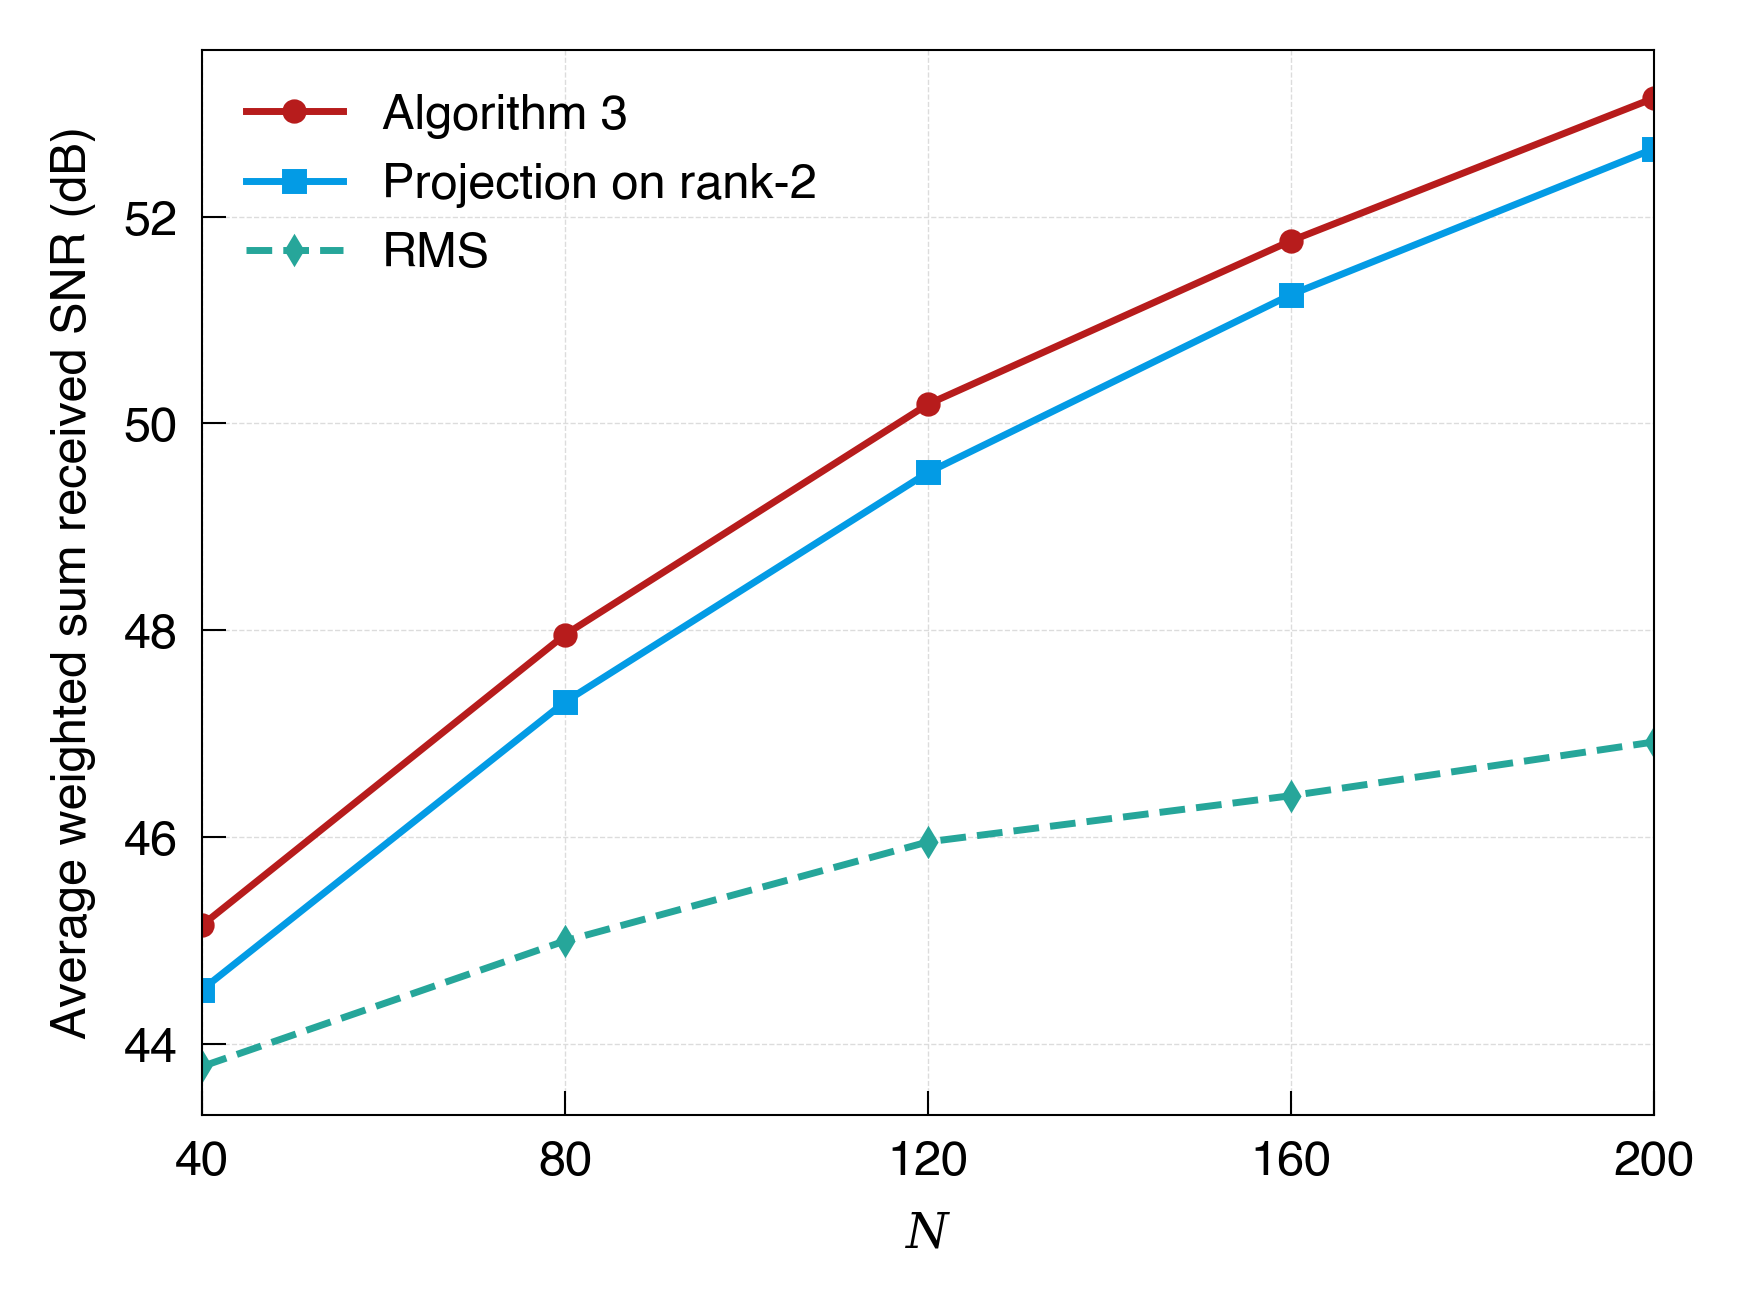

In [19]:
# Monte Carlo comparison over RIS size N (average SNR in dB)
N_LIST = np.array([40, 80, 120, 160, 200])
TRIALS = 200
RMS_SAMPLES = 500
ALG1_RANK = 8
ALG1_MAX_ITER = 120
ALG1_RESTARTS = 24
RNG_SEED = 2026
rng = np.random.default_rng(RNG_SEED)

algo1_mean_db = []
algo2_mean_db = []
rms_mean_db = []

for N in N_LIST:
    # rebuild system for this RIS size
    ris_n = node.RIS(x=0.0, y=0.0, z=2.0, N=int(N))
    users_n = equal_distance_users(ris_n, num_users=N_USERS, radius=USER_RADIUS, z=1.5)
    sys_n = system.MultiUserSystem(TX, ris_n, users_n)

    algo1_trials = np.zeros(TRIALS)
    algo2_trials = np.zeros(TRIALS)
    rms_trials = np.zeros(TRIALS)

    for t in range(TRIALS):
        # regenerate channels in each trial
        sys_n.gen_channels(is_los=LOS)

        # Algorithm 1: Alternating (random minimization / random initialization)
        _, obj1 = run_algo1_alternating(
            sys_n,
            rank=ALG1_RANK,
            max_iter=ALG1_MAX_ITER,
            restarts=ALG1_RESTARTS,
            rng=rng
        )

        # Algorithm 2: rank-2 projected solve (no alternating iterations)
        _, obj2, _ = run_algo2_rank2_projection(sys_n)

        # RMS algorithm: sample-based binary phase benchmark
        _, obj_rms = run_algo_rms(sys_n, num_samples=RMS_SAMPLES, rng=rng)

        algo1_trials[t] = obj1
        algo2_trials[t] = obj2
        rms_trials[t] = obj_rms

    # convert average objective to dB
    mean_obj1 = np.mean(algo1_trials)
    mean_obj2 = np.mean(algo2_trials)
    mean_obj_rms = np.mean(rms_trials)
    algo1_mean_db.append(10 * np.log10(np.maximum(mean_obj1, 1e-12)))
    algo2_mean_db.append(10 * np.log10(np.maximum(mean_obj2, 1e-12)))
    rms_mean_db.append(10 * np.log10(np.maximum(mean_obj_rms, 1e-12)))

    print(
        f'Finished N={int(N)}: algo1={algo1_mean_db[-1]:.3f} dB, algo2={algo2_mean_db[-1]:.3f} dB, rms={rms_mean_db[-1]:.3f} dB'
    )

algo1_mean_db = np.array(algo1_mean_db)
algo2_mean_db = np.array(algo2_mean_db)
rms_mean_db = np.array(rms_mean_db)

plot_colors = setup_multiuser_plot_style()

plt.figure(figsize=(3.5, 2.625), dpi=500)
plt.plot(N_LIST, algo1_mean_db, marker='o', markersize=2.5, label='Algorithm 3',
         color=plot_colors[0], linewidth=1.0)
plt.plot(N_LIST, algo2_mean_db, marker='s', markersize=2.5, label='Projection on rank-2',
         color=plot_colors[1], linewidth=1.0)
plt.plot(N_LIST, rms_mean_db, marker='d', markersize=2.0, linestyle='--', label='RMS',
         color=plot_colors[2], linewidth=1.0)
plt.xlabel(r'$N$')
plt.ylabel('Average weighted sum received SNR (dB)')
plt.xlim([N_LIST.min(), N_LIST.max()])
plt.xticks(N_LIST)
leg = plt.legend(frameon=False, edgecolor='black', framealpha=0.8)
leg.get_frame().set_linewidth(0.4)
plt.grid(color='gainsboro', linestyle='--', linewidth=0.2)
plt.tight_layout()


## Algorithm 1 convergence trace in one representative trial
To verify monotonic behavior and convergence, this cell reruns Algorithm 1 once and plots the objective after each alternating update.


Convergence N=120: final=49.666 dB, stored=6 iters
Convergence N=200: final=52.957 dB, stored=6 iters


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_30265/3793982323.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_col.T @ M @ x_col + w.T @ x_col + c)


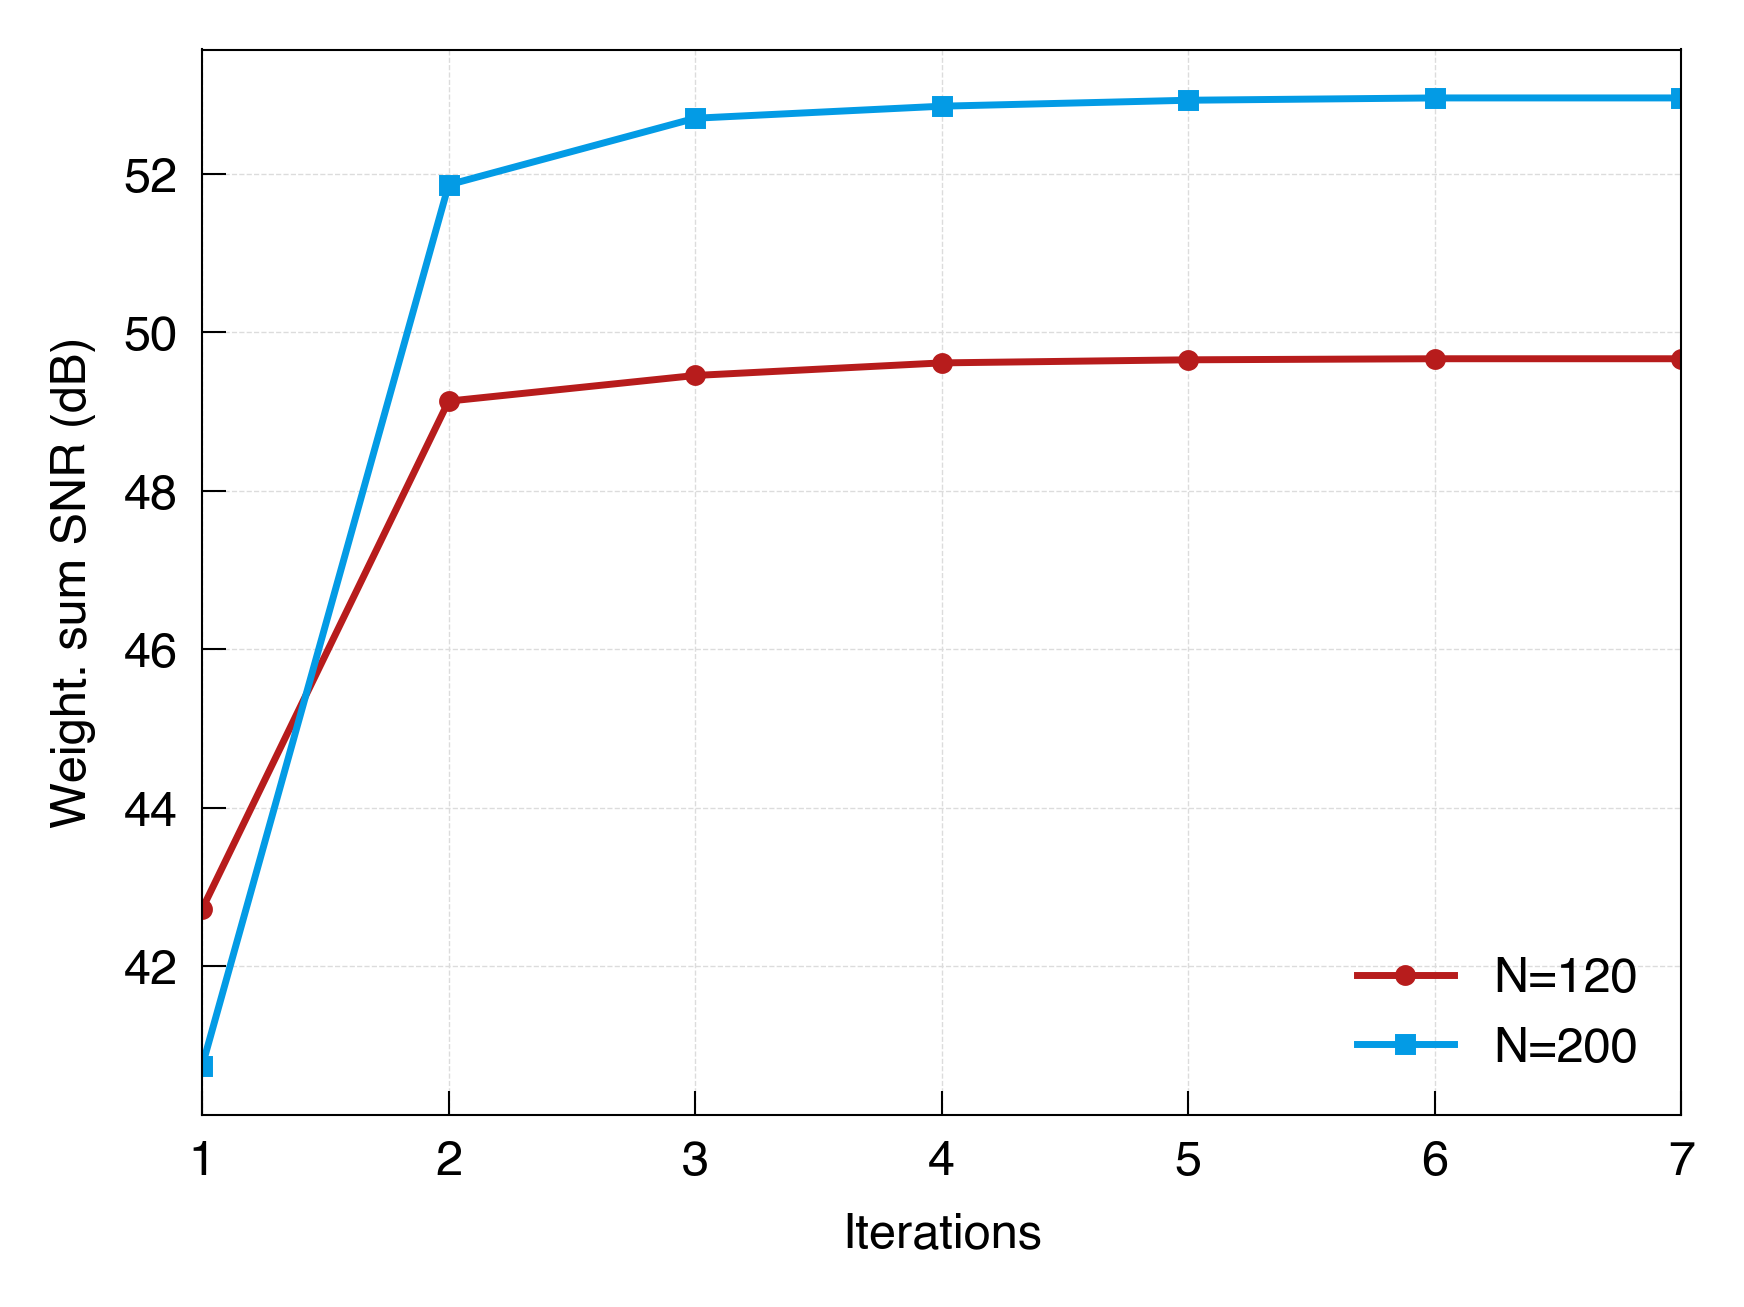

In [35]:
# Fresh channel sample for trace
TRACE_TRIAL_SEED = 12345
TRACE_RIS_LIST = [int(N_RIS), 200]
TRACE_RIS_LIST = sorted(set(TRACE_RIS_LIST))
TRACE_MAX_ITER = ALG1_MAX_ITER
TRACE_RANK = ALG1_RANK
trace_results = {}

for idx, N_t in enumerate(TRACE_RIS_LIST):
    ris_t = node.RIS(x=0.0, y=0.0, z=2.0, N=int(N_t))
    users_t = equal_distance_users(ris_t, num_users=N_USERS, radius=USER_RADIUS, z=1.5)
    sys_t = system.MultiUserSystem(TX, ris_t, users_t)

    sys_t.gen_channels(is_los=LOS)
    rng_t = np.random.default_rng(TRACE_TRIAL_SEED + idx + 10)
    _, _, obj_history = run_algo1_trace(
        sys_t,
        rank=TRACE_RANK,
        max_iter=TRACE_MAX_ITER,
        rng=rng_t
    )

    trace_results[int(N_t)] = 10 * np.log10(np.maximum(obj_history, 1e-12))
    print(
        f'Convergence N={N_t}: final={trace_results[int(N_t)][-1]:.3f} dB, stored={len(trace_results[int(N_t)]) - 1} iters'
    )

trace_N_sorted = sorted(trace_results.keys())
max_len = max(len(trace_results[n]) for n in trace_N_sorted)
trace_iterations = np.arange(1, max_len + 1)

plot_colors = setup_multiuser_plot_style()

plt.figure(figsize=(3.5, 2.625), dpi=500)
for ii, n in enumerate(trace_N_sorted):
    hist = trace_results[n]
    x_axis = np.arange(1, len(hist) + 1)
    marker = 'o' if ii == 0 else 's'
    plt.plot(x_axis, hist, marker=marker, markersize=2, color=plot_colors[ii], linewidth=1.0, label=f'N={n}')

plt.xlabel('Iterations')
plt.ylabel('Weight. sum SNR (dB)')
plt.xlim([1, max_len])
plt.xticks(trace_iterations[::max(1, max_len//6)])
leg = plt.legend(frameon=False, edgecolor='black', framealpha=0.8)
leg.get_frame().set_linewidth(0.4)
plt.grid(color='gainsboro', linestyle='--', linewidth=0.2)
plt.tight_layout()


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_30265/2686632713.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


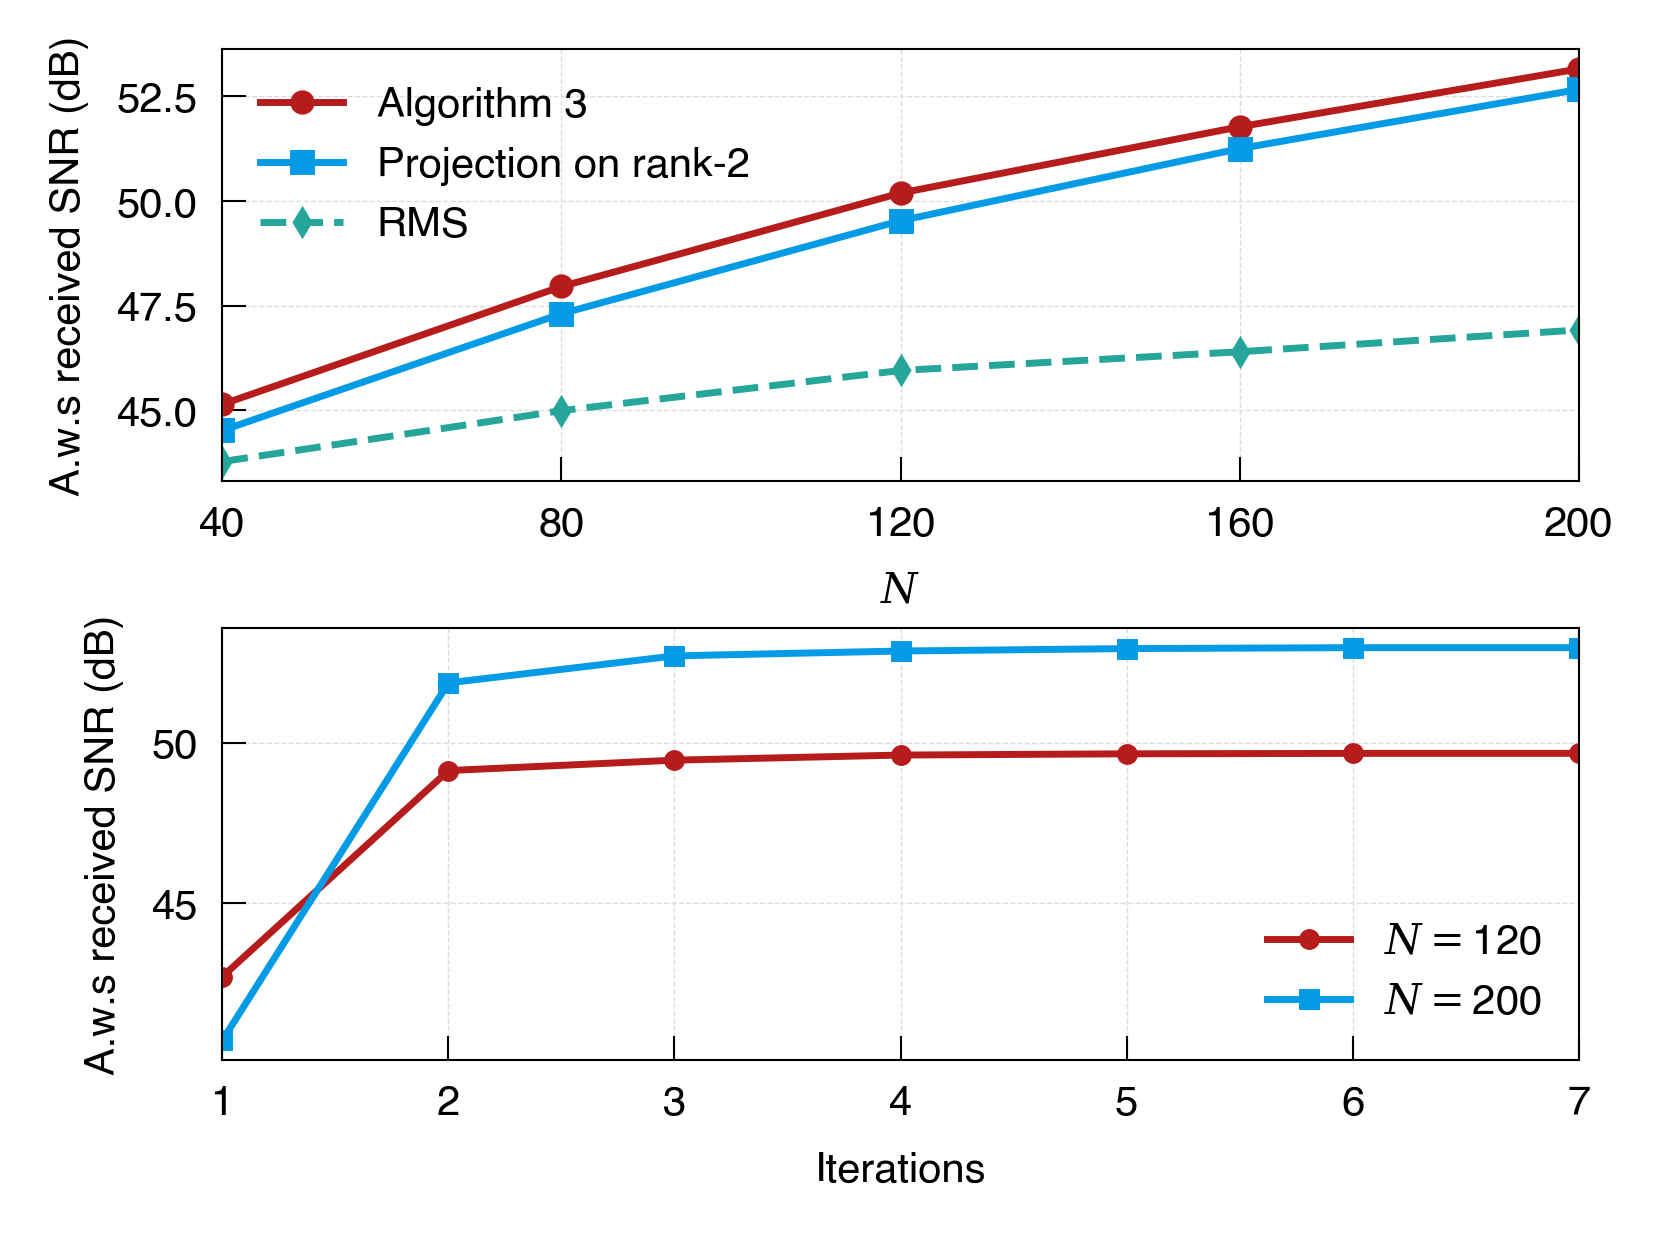

In [41]:
# Stacked plot: RIS-size comparison (top) and convergence trace (bottom)
plot_colors = setup_multiuser_plot_style()

# keep final combined figure compact
FIG_SMALL_FONTSIZE = 6
fig, axes = plt.subplots(2, 1, figsize=(3.5, 2.625), dpi=500, sharex=False,
                      gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.34})

# Top: Monte Carlo average SNR vs RIS size
axes[0].plot(N_LIST, algo1_mean_db, marker='o', markersize=2.5, label='Algorithm 3',
             color=plot_colors[0], linewidth=1.0)
axes[0].plot(N_LIST, algo2_mean_db, marker='s', markersize=2.5, label='Projection on rank-2',
             color=plot_colors[1], linewidth=1.0)
axes[0].plot(N_LIST, rms_mean_db, marker='d', markersize=2.0, linestyle='--', label='RMS',
             color=plot_colors[2], linewidth=1.0)
axes[0].set_xlabel(r'$N$', fontsize=FIG_SMALL_FONTSIZE)
axes[0].set_ylabel('A.w.s received SNR (dB)', fontsize=FIG_SMALL_FONTSIZE)
axes[0].set_xlim([N_LIST.min(), N_LIST.max()])
axes[0].set_xticks(N_LIST)
axes[0].tick_params(labelsize=FIG_SMALL_FONTSIZE)
leg0 = axes[0].legend(frameon=False, edgecolor='black', framealpha=0.8, fontsize=FIG_SMALL_FONTSIZE)
leg0.get_frame().set_linewidth(0.4)
axes[0].grid(color='gainsboro', linestyle='--', linewidth=0.2)

# Bottom: convergence trace for two RIS sizes
for ii, n in enumerate(trace_N_sorted):
    hist = trace_results[n]
    x_axis = np.arange(1, len(hist) + 1)
    marker = 'o' if ii == 0 else 's'
    axes[1].plot(x_axis, hist, marker=marker, markersize=2, color=plot_colors[ii], linewidth=1.0,
                 label=f'$N=${n}')

max_len = max(len(trace_results[n]) for n in trace_N_sorted)
axes[1].set_xlabel('Iterations', fontsize=FIG_SMALL_FONTSIZE)
axes[1].set_ylabel('A.w.s received SNR (dB)', fontsize=FIG_SMALL_FONTSIZE)
axes[1].set_xlim([1, max_len])
axes[1].set_xticks(np.arange(1, max_len + 1)[::max(1, max_len//6)])
axes[1].tick_params(labelsize=FIG_SMALL_FONTSIZE)
leg1 = axes[1].legend(frameon=False, edgecolor='black', framealpha=0.8, fontsize=FIG_SMALL_FONTSIZE)
leg1.get_frame().set_linewidth(0.4)
axes[1].grid(color='gainsboro', linestyle='--', linewidth=0.2)
fig.tight_layout()
plt.savefig('fig_multiuser.pdf', dpi=500, bbox_inches='tight', pad_inches=0.05)
